:
# Visualization Google Colab Of Self-Reported Scores
@Author: Philippe Wyder  
(Modified by Alexey Yermakov)
---



## Imports / Flags


In [ ]:
%load_ext autoreload
%autoreload 2

import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

from visualize_scores_helpers import *  # noqa: F403 E402 # pyrefly: ignore

# DPI for publication-quality figures
NEURIPS_DPI = 300

# We'll populate these after loading data
GLOBAL_MODEL_COLORS = {}
GLOBAL_MODEL_MARKERS = {}
GLOBAL_MODEL_PATTERNS = {}

# Load Data

In [ ]:
# Paths to data
ks_csv = Path(os.getcwd()) / "KS.csv"
lorenz_csv = Path(os.getcwd()) / "Lorenz.csv"

# Load the data
data = load_sheets_data([lorenz_csv, ks_csv])  # noqa: F405 # pyrefly: ignore
data = {{"Lorenz": "Lorenz", "KS": "KS"}[key]: value for key, value in data.items() if key in ["Lorenz", "KS"]}

# Create global color mapping for all models
if data:
    all_models = set()
    for df in data.values():
        all_models.update(df["Model"].unique())

    GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS = create_model_color_mapping(list(all_models))  # noqa: F405 # pyrefly: ignore
    print(f"\nCreated color mapping for {len(GLOBAL_MODEL_COLORS)} models")
    print(f"Created marker mapping for {len(GLOBAL_MODEL_MARKERS)} models")
    print(f"Created pattern mapping for {len(GLOBAL_MODEL_PATTERNS)} models")

Lorenz loaded: 15 rows (after cleaning), 26 columns
KS loaded: 14 rows (after cleaning), 26 columns

Replaced NaN values with -100.0 in Lorenz

Replaced NaN values with -100.0 in KS

Created color mapping for 15 models
Created marker mapping for 15 models
Created pattern mapping for 15 models


# Basic Data Exploration

In [ ]:
# Explore the cleaned data
if data:
    explore_cleaned_data(data)  # noqa: F405 # pyrefly: ignore


Sheet: Lorenz

Shape: (15, 26)

Models included: ['Baseline Zeros', 'Baseline Average', 'Reservoir', 'KAN', 'HigherOrder DMD', 'Opt DMD', 'PyKoopman', 'LSTM', 'ODE-LSTM', 'Spacetime', 'DeepONet', 'SINDy', 'FNO', 'NeuralODE', 'PINN']

First 5 rows:


,Model,avg_score,E1 mean,E1 std,E2 mean,E2 std,E3 mean,E3 std,E4 mean,E4 std,...,E8 mean,E8 std,E9 mean,E9 std,E10 mean,E10 std,E11 mean,E11 std,E12 mean,E12 std
0,Baseline Zeros,-39.00,0.00,0.00,-93.33,0.00,0.00,0.00,-93.47,0.00,...,-93.73,0.00,0.00,0.00,-93.73,0.00,0.00,0.00,0.00,0.00
1,Baseline Average,-4.73,51.71,0.00,-91.20,0.00,54.88,0.00,-91.87,0.00,...,-91.07,0.00,51.93,0.00,-90.27,0.00,57.08,0.00,60.88,0.00
2,Reservoir,54.87,99.91,0.06,56.72,10.00,97.41,0.01,-33.49,70.39,...,61.92,9.21,45.41,0.84,-48.51,24.31,99.80,0.12,99.97,0.00
3,KAN,47.28,82.89,26.43,20.53,58.61,96.19,0.06,55.20,3.28,...,-2.45,34.69,33.68,4.41,-31.47,38.67,41.69,3.90,60.85,0.17
4,HigherOrder DMD,0.94,51.77,0.00,-84.40,0.00,54.88,0.00,-90.53,0.00,...,-81.60,0.00,49.74,0.00,-11.33,0.00,59.04,0.00,31.22,0.00



Basic statistics (numeric columns only):


,avg_score,E1 mean,E1 std,E2 mean,E2 std,E3 mean,E3 std,E4 mean,E4 std,E5 mean,...,E8 mean,E8 std,E9 mean,E9 std,E10 mean,E10 std,E11 mean,E11 std,E12 mean,E12 std
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,...,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,21.758667,61.814667,3.245333,-6.692667,18.779333,63.562000,0.078667,-14.331333,17.075333,58.507333,...,-19.408667,12.593333,28.188667,9.546000,-28.996000,10.480000,54.818667,2.094000,49.610667,2.645333
std,29.099993,31.079739,7.382308,67.724594,24.964772,28.233139,0.193902,64.500072,26.782593,35.895417,...,61.585054,13.427017,37.438479,25.473252,49.114962,12.591056,27.255092,4.033575,24.856946,5.489239
min,-39.000000,0.000000,0.000000,-93.330000,0.000000,0.000000,0.000000,-96.800000,0.000000,-29.220000,...,-94.530000,0.000000,-100.000000,0.000000,-96.400000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.160000,47.140000,0.000000,-75.865000,0.000000,54.285000,0.000000,-89.600000,0.000000,55.880000,...,-87.310000,0.000000,33.400000,0.000000,-81.935000,0.000000,35.625000,0.000000,34.625000,0.000000
50%,20.510000,52.080000,0.060000,17.070000,10.000000,54.970000,0.010000,-9.470000,2.740000,56.510000,...,8.670000,9.210000,36.830000,2.050000,-15.730000,1.780000,57.080000,0.000000,57.950000,0.000000
75%,44.475000,90.330000,0.610000,48.825000,31.180000,96.210000,0.075000,51.575000,21.645000,92.420000,...,28.215000,23.745000,44.645000,3.655000,14.560000,21.415000,78.950000,2.010000,60.865000,0.095000
max,64.540000,99.910000,26.430000,89.870000,75.340000,97.900000,0.760000,69.920000,70.390000,96.480000,...,61.920000,34.690000,51.930000,100.000000,32.530000,38.670000,99.800000,13.080000,99.970000,14.490000



Missing values in task scores (E1-E12):
Series([], dtype: int64)

Average score range: -39.00 to 64.54

Sheet: KS

Shape: (14, 26)

Models included: ['Baseline Zeros', 'Baseline Average', 'Reservoir', 'KAN', 'HigherOrder DMD', 'Opt DMD', 'PyKoopman', 'LSTM', 'ODE-LSTM', 'Spacetime', 'DeepONet', 'SINDy', 'FNO', 'NeuralODE']

First 5 rows:


,Model,avg_score,E1 mean,E1 std,E2 mean,E2 std,E3 mean,E3 std,E4 mean,E4 std,...,E8 mean,E8 std,E9 mean,E9 std,E10 mean,E10 std,E11 mean,E11 std,E12 mean,E12 std
0,Baseline Zeros,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,Baseline Average,-2.76,-3.39,0.00,4.34,0.00,0.01,0.00,0.13,0.00,...,7.66,0.00,-7.12,0.00,15.67,0.00,-27.97,0.00,-13.88,0.00
2,Reservoir,18.32,99.97,0.00,86.45,1.75,88.61,0.04,18.52,14.25,...,7.43,18.11,-100.00,30.40,-100.00,100.00,32.39,4.16,40.08,3.93
3,KAN,9.19,-4.43,1.11,16.74,1.16,50.36,0.86,2.17,2.45,...,32.97,19.49,-43.06,15.77,32.83,13.72,0.83,0.17,-2.75,2.67
4,HigherOrder DMD,-33.57,-100.00,100.00,-100.00,100.00,0.00,0.00,0.00,0.00,...,-100.00,100.00,-0.03,0.07,-100.00,100.00,0.00,0.00,0.46,0.00



Basic statistics (numeric columns only):


,avg_score,E1 mean,E1 std,E2 mean,E2 std,E3 mean,E3 std,E4 mean,E4 std,E5 mean,...,E8 mean,E8 std,E9 mean,E9 std,E10 mean,E10 std,E11 mean,E11 std,E12 mean,E12 std
count,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,...,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000
mean,-5.328571,33.053571,15.890000,-8.511429,29.483571,18.912143,2.160714,-3.327857,7.933571,14.015714,...,-23.716429,42.938571,-28.281429,7.144286,-14.560000,32.350714,-12.351429,1.505714,-2.408571,2.549286
std,21.392973,58.649993,35.876133,54.736676,39.964771,56.095910,5.406878,45.036307,11.342657,49.541014,...,63.689848,46.128683,38.403333,10.573851,57.495393,44.730807,27.277204,3.091743,20.633021,6.562010
min,-55.050000,-100.000000,0.000000,-100.000000,0.000000,-100.000000,0.000000,-100.000000,0.000000,-100.000000,...,-100.000000,0.000000,-100.000000,0.000000,-100.000000,0.000000,-54.620000,0.000000,-41.150000,0.000000
25%,-10.230000,-2.542500,0.000000,-7.527500,0.297500,-1.087500,0.000000,0.000000,0.000000,0.000000,...,-100.000000,1.335000,-53.642500,0.000000,-71.647500,0.015000,-30.452500,0.000000,-10.257500,0.000000
50%,-1.430000,40.005000,0.420000,4.560000,11.300000,0.005000,0.005000,4.470000,4.455000,3.345000,...,3.715000,18.800000,-7.010000,1.850000,4.105000,10.500000,0.000000,0.000000,0.240000,0.005000
75%,9.170000,83.307500,3.165000,15.655000,34.407500,78.170000,0.055000,16.412500,8.987500,48.367500,...,29.932500,100.000000,-0.505000,8.325000,27.692500,78.930000,2.320000,0.215000,8.087500,2.057500
max,18.570000,99.970000,100.000000,86.450000,100.000000,90.110000,17.510000,74.460000,38.590000,80.730000,...,57.950000,100.000000,6.370000,30.400000,55.700000,100.000000,32.390000,9.300000,40.080000,24.730000



Missing values in task scores (E1-E12):
Series([], dtype: int64)

Average score range: -55.05 to 18.57


# Define Bar Plot
Here we define the function for creating the bar plot of the top-few methods & a baseline

All models: ['Baseline Average', 'Baseline Zeros', 'DeepONet', 'FNO', 'HigherOrder DMD', 'KAN', 'LSTM', 'NeuralODE', 'ODE-LSTM', 'Opt DMD', 'PINN', 'PyKoopman', 'Reservoir', 'SINDy', 'Spacetime']


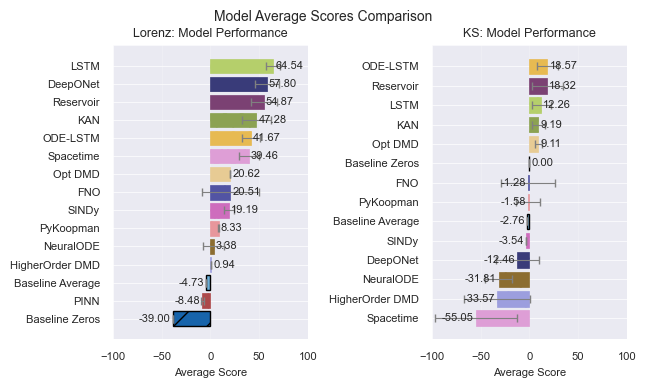

In [ ]:
# Create model comparison plots
create_model_comparison_plots(  # pyrefly: ignore
    data, size=(6.5, 4), globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI) # noqa: F405
) 


# Define Spider Plot
Here we define the function for creating the spider plot of the top four methods that dominate the compound score.

In [5]:
import pprint as pp

pp.pprint(GLOBAL_MODEL_COLORS)
pp.pprint(GLOBAL_MODEL_MARKERS)
GLOBAL_MODEL_MARKERS["LSTM"] = "+"
GLOBAL_MODEL_COLORS["LSTM"] = GLOBAL_MODEL_COLORS["FNO"]

{'Baseline Average': array([0.41708574, 0.68063053, 0.83823145, 1.        ]),
 'Baseline Zeros': array([0.09019608, 0.39294118, 0.67058824, 1.        ]),
 'DeepONet': array([0.22352941, 0.23137255, 0.4745098 , 1.        ]),
 'FNO': array([0.32156863, 0.32941176, 0.63921569, 1.        ]),
 'HigherOrder DMD': array([0.61176471, 0.61960784, 0.87058824, 1.        ]),
 'KAN': array([0.54901961, 0.63529412, 0.32156863, 1.        ]),
 'LSTM': array([0.70980392, 0.81176471, 0.41960784, 1.        ]),
 'NeuralODE': array([0.54901961, 0.42745098, 0.19215686, 1.        ]),
 'ODE-LSTM': array([0.90588235, 0.72941176, 0.32156863, 1.        ]),
 'Opt DMD': array([0.90588235, 0.79607843, 0.58039216, 1.        ]),
 'PINN': array([0.67843137, 0.28627451, 0.29019608, 1.        ]),
 'PyKoopman': array([0.90588235, 0.58823529, 0.61176471, 1.        ]),
 'Reservoir': array([0.48235294, 0.25490196, 0.45098039, 1.        ]),
 'SINDy': array([0.80784314, 0.42745098, 0.74117647, 1.        ]),
 'Spacetime': arra

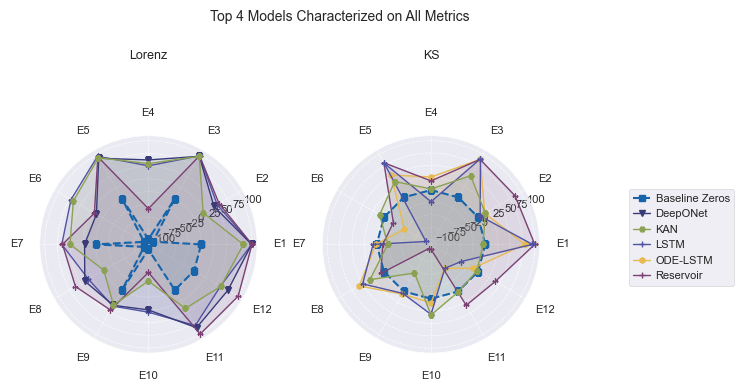

In [ ]:
# Create spider plots
create_spider_plots(  # pyrefly: ignore
    data,
    size=(8, 3.5),
    n_top_models=4,
    globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI),
)  # noqa: F405

# Barplot Comparison top models per metric per dataset

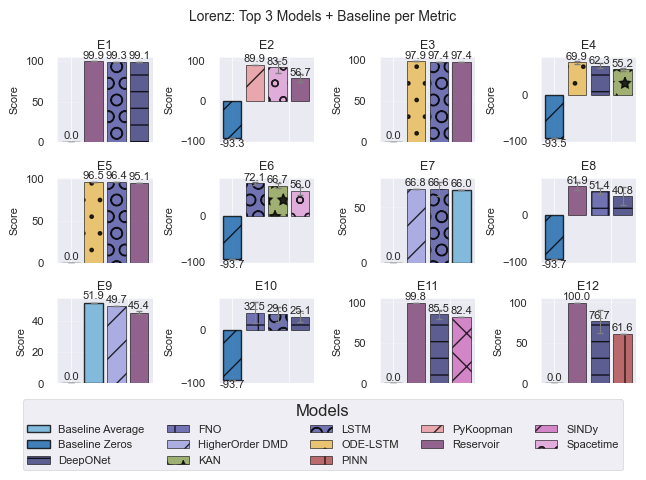

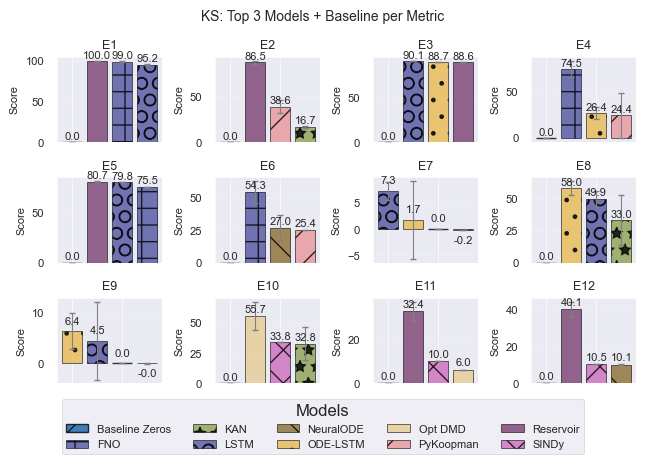

In [ ]:
# Create compound bar plots
create_compound_bar_plots(  # pyrefly: ignore
    data, size=(6.5, 4), globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI)
)  # noqa: F405

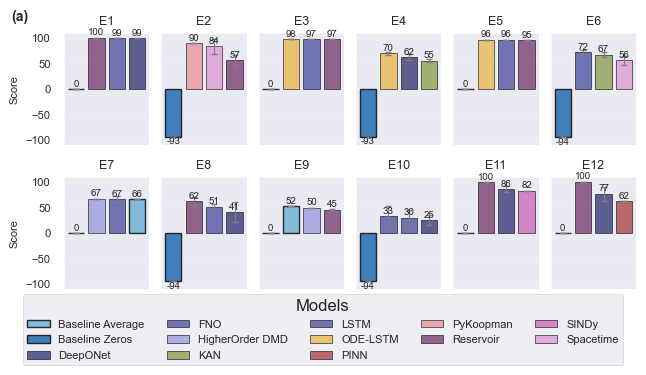

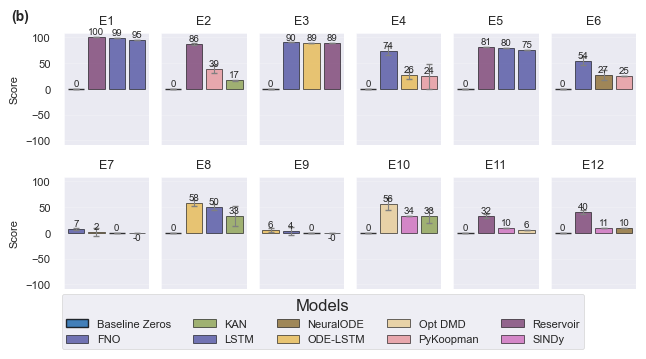

In [ ]:
# Create compact compound bar plots
create_compact_compound_bar_plots(  # pyrefly: ignore
    data, size=(6.5, 3), globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI)
)  # noqa: F405

# Condensed Plot with baseline as dashed line across graph

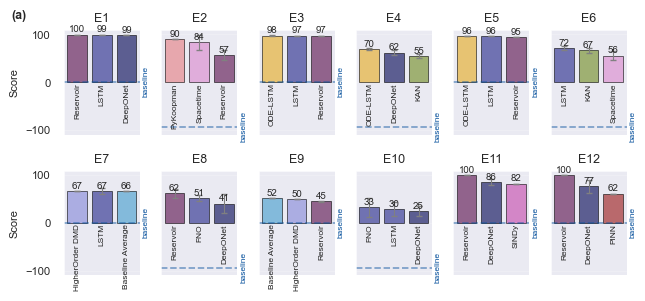

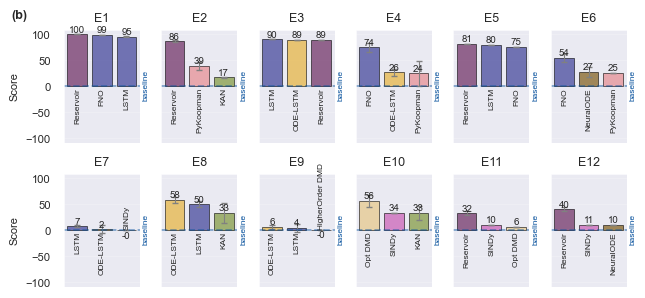

In [ ]:
# Create ultra-compact compound bar plots without patterns
create_ultra_compact_bar_plots(  # pyrefly: ignore
    data,
    size=(6.5, 3),
    use_patterns=False,
    globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI),
)  # noqa: F405

# Generate Plots

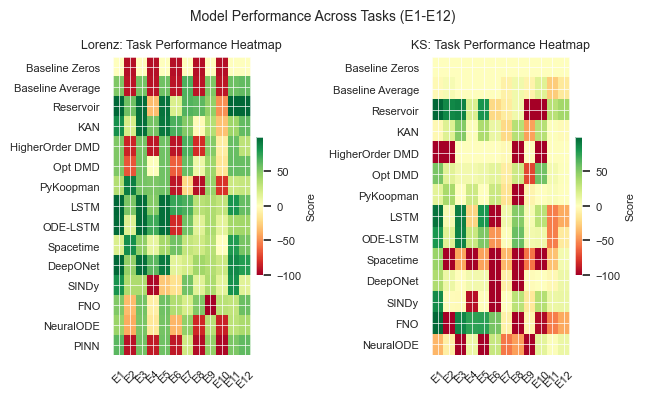

In [ ]:
# Create task performance heatmaps
create_task_performance_heatmaps(  # pyrefly: ignore
    data, size=(6.5, 4), globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI)
)  # noqa: F405

# Comparative Analysis

In [ ]:
# Create interactive task comparison
create_interactive_task_comparison(data)  # noqa: F405 # pyrefly: ignore

# Statistical Analysis

<class 'numpy.ndarray'>
1
<class 'numpy.ndarray'>
1


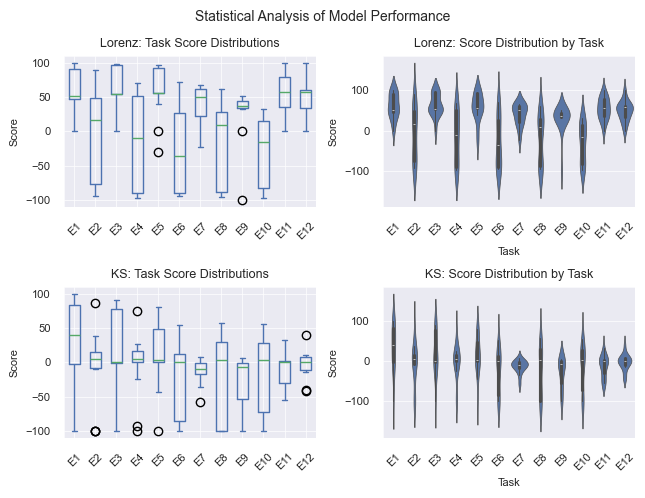


Summary Statistics:

Lorenz:
  Number of models: 15
  Average score range: -39.00 to 64.54
  Mean of average scores: 21.76
  Std of average scores: 29.10
  Best performing model: LSTM (score: 64.54)
  Worst performing model: Baseline Zeros (score: -39.00)

KS:
  Number of models: 14
  Average score range: -55.05 to 18.57
  Mean of average scores: -5.33
  Std of average scores: 21.39
  Best performing model: ODE-LSTM (score: 18.57)
  Worst performing model: Spacetime (score: -55.05)


In [ ]:
# Perform statistical analysis
statistical_analysis(  # pyrefly: ignore
    data, size=(6.5, 5), globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI)
)  # noqa: F405

# Rankings

In [ ]:
# Create model rankings
create_model_rankings(data, globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI))  # noqa: F405 # pyrefly: ignore


Model Rankings:

Lorenz Rankings:
 rank            Model  avg_score
    1             LSTM      64.54
    2         DeepONet      57.80
    3        Reservoir      54.87
    4              KAN      47.28
    5         ODE-LSTM      41.67
    6        Spacetime      39.46
    7          Opt DMD      20.62
    8              FNO      20.51
    9            SINDy      19.19
   10        PyKoopman       8.33
   11        NeuralODE       3.38
   12  HigherOrder DMD       0.94
   13 Baseline Average      -4.73
   14             PINN      -8.48
   15   Baseline Zeros     -39.00

KS Rankings:
 rank            Model  avg_score
    1         ODE-LSTM      18.57
    2        Reservoir      18.32
    3             LSTM      12.26
    4              KAN       9.19
    5          Opt DMD       9.11
    6   Baseline Zeros       0.00
    7              FNO      -1.28
    8        PyKoopman      -1.58
    9 Baseline Average      -2.76
   10            SINDy      -3.54
   11         DeepONet     -12.46

## Rankings: Matplotlib Version

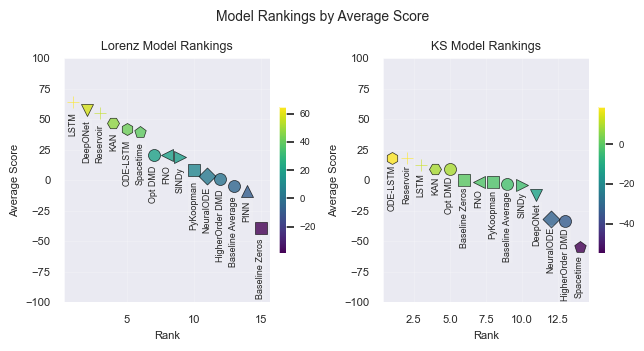


Model Rankings:

Lorenz Rankings:
 rank            Model  avg_score
    1             LSTM      64.54
    2         DeepONet      57.80
    3        Reservoir      54.87
    4              KAN      47.28
    5         ODE-LSTM      41.67
    6        Spacetime      39.46
    7          Opt DMD      20.62
    8              FNO      20.51
    9            SINDy      19.19
   10        PyKoopman       8.33
   11        NeuralODE       3.38
   12  HigherOrder DMD       0.94
   13 Baseline Average      -4.73
   14             PINN      -8.48
   15   Baseline Zeros     -39.00


KS Rankings:
 rank            Model  avg_score
    1         ODE-LSTM      18.57
    2        Reservoir      18.32
    3             LSTM      12.26
    4              KAN       9.19
    5          Opt DMD       9.11
    6   Baseline Zeros       0.00
    7              FNO      -1.28
    8        PyKoopman      -1.58
    9 Baseline Average      -2.76
   10            SINDy      -3.54
   11         DeepONet     -12.4

In [ ]:
# Create model rankings with Matplotlib
create_model_rankings_matplotlib(  # pyrefly: ignore
    data, size=(6.5, 3.5), globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI)
)  # noqa: F405

# Generate Latex Tables

In [ ]:
# Create LaTeX tables
latex_tables = create_latex_performance_tables(data)  # noqa: F405 # pyrefly: ignore

KeyError: 'E1'

# Save Results

In [ ]:
# save_analysis_results(data, save_path='')